In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import scipy as sp

sns.set_theme(style="darkgrid")  # darkgrid is closest to ggplot
# or use Matplotlib style for ggplot
#plt.style.use('ggplot')

Exampls for Bayesian Inference

# Example 1

### Generate dummy data


In [49]:
np.random.seed(42)
true_mu = 5
true_sigma = 2
data = np.random.normal(true_mu, true_sigma, size=100)

### Definition prior hyperparameters

In [4]:
prior_mu_mean = 0
prior_mu_precision = 1  # Variance = 1 / precision

prior_sigma_alpha = 2
prior_sigma_beta = 2  # Beta = alpha / beta

### Update prior hyperparameters with example data (fitting)

In [5]:
posterior_mu_precision = prior_mu_precision + len(data) / true_sigma**2
posterior_mu_mean = (prior_mu_precision * prior_mu_mean + np.sum(data)) / posterior_mu_precision

posterior_sigma_alpha = prior_sigma_alpha + len(data) / 2
posterior_sigma_beta = prior_sigma_beta + np.sum((data - np.mean(data))**2) / 2


### Calculate the posterior parameters

In [6]:
posterior_mu = np.random.normal(posterior_mu_mean, 1 / np.sqrt(posterior_mu_precision), size=10000)
posterior_sigma = np.random.gamma(posterior_sigma_alpha, 1 / posterior_sigma_beta, size=10000)


## Results

### Plot Posterior Distribution

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3264980168.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Posterior distribution of $\mu$')
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3264980168.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3264980168.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Posterior distribution of $\sigma$')
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3264980168.py:11: SyntaxWarning: 

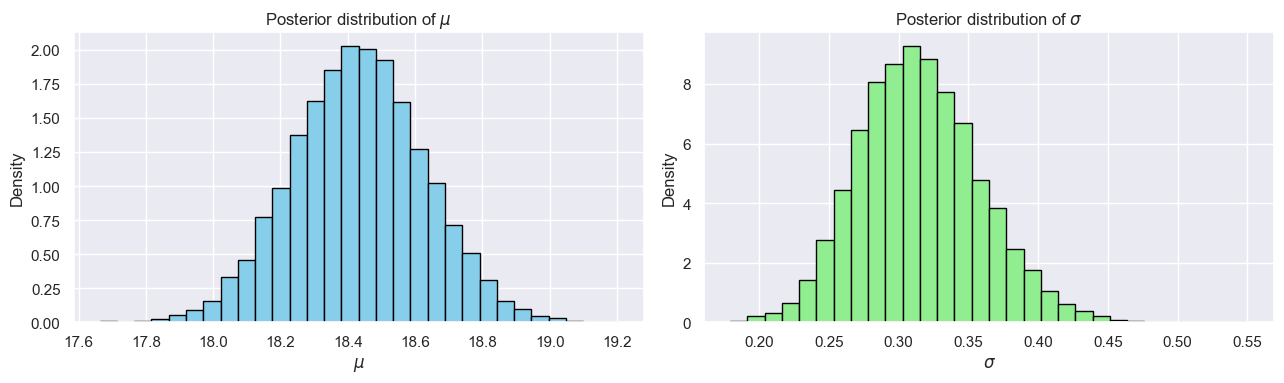

In [50]:
plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
plt.hist(posterior_mu, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Posterior distribution of $\mu$')
plt.xlabel('$\mu$')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
plt.hist(posterior_sigma, bins=30, density=True, color='lightgreen', edgecolor='black')
plt.title('Posterior distribution of $\sigma$')
plt.xlabel('$\sigma$')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

### Summary statistics

In [11]:
mean_mu = np.mean(posterior_mu)
std_mu = np.std(posterior_mu)
print("Mean of mu:", mean_mu)
print("Standard deviation of mu:", std_mu)

mean_sigma = np.mean(posterior_sigma)
std_sigma = np.std(posterior_sigma)
print("Mean of sigma:", mean_sigma)
print("Standard deviation of sigma:", std_sigma)

Mean of mu: 18.431718658085725
Standard deviation of mu: 0.19684004415211634
Mean of sigma: 0.314978331043776
Standard deviation of sigma: 0.043338268607342946


-----


# Example 2
Predicting Website Conversion Rates with Bayesian Inference

In [12]:
# Observed data
num_visitors = 1000  # Total number of visitors to the website
num_conversions = 50  # Number of conversions (desired actions)


### Prior hyperparameters for the Beta distribution

In [13]:
prior_alpha = 1  # Shape parameter
prior_beta = 1   # Shape parameter

### Fitting - Update Prior with Observed Data == Posterior Parameters

In [14]:
posterior_alpha = prior_alpha + num_conversions
posterior_beta = prior_beta + (num_visitors - num_conversions)


### Generate Samples from the Posterior Beta Distribution

In [15]:
posterior_samples = np.random.beta(posterior_alpha, posterior_beta, size=10000)

## Results

### Plot Posterior Distribution

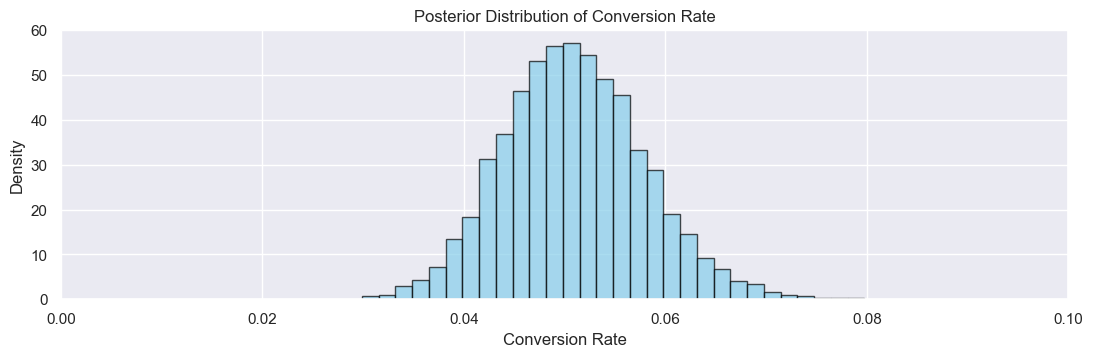

In [51]:
plt.figure(figsize=(13, 3.5))
plt.hist(posterior_samples, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Posterior Distribution of Conversion Rate')
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.xlim(0, 0.1)  # Limiting x-axis to focus on conversion rates close to zero
plt.show()


### Calculate Summary Statistics

In [20]:
mean_conversion_rate = posterior_alpha / (posterior_alpha + posterior_beta)
mode_conversion_rate = (posterior_alpha - 1) / (posterior_alpha + posterior_beta - 2)  # Mode of the Beta distribution

print("Mean conversion rate:", mean_conversion_rate)
print("Mode conversion rate:", mode_conversion_rate)

Mean conversion rate: 0.05089820359281437
Mode conversion rate: 0.05


---

# Example 3


[How to use Bayesian Inference for predictions in Python](https://towardsdatascience.com/how-to-use-bayesian-inference-for-predictions-in-python-4de5d0bc84f3/)


**Sneaky Advanced Note** 

I'm using the uniform distribution for clarity, but we can also make the beta distribution look completely flat by tweaking alpha and beta!

In [22]:
mu = np.linspace(1.65, 1.8, num = 50)
test = np.linspace(0, 2)

uniform_dist = sp.stats.uniform.pdf(mu) + 1 
uniform_dist

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [23]:
# Normalizing the distribution to make the probability densities sum into 1
uniform_dist = uniform_dist/uniform_dist.sum() 

beta_dist = sp.stats.beta.pdf(mu, 2, 5, loc = 1.65, scale = 0.2) 
beta_dist = beta_dist/beta_dist.sum()

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/831247452.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Value of $\mu$ in meters")


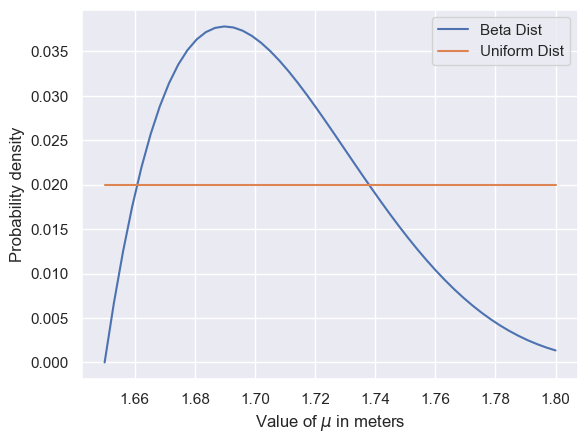

In [52]:
plt.plot(mu, beta_dist, label = 'Beta Dist')
plt.plot(mu, uniform_dist, label = 'Uniform Dist')
plt.xlabel("Value of $\mu$ in meters")
plt.ylabel("Probability density")
plt.legend()
plt.show()

In [27]:
# Note that mu here is an array of values, so the output is also an array!
def likelihood_func(datum, mu):
    likelihood_out = sp.stats.norm.pdf(datum, mu, scale = 0.1) 
    return likelihood_out/likelihood_out.sum()

In [28]:
likelihood_out = likelihood_func(1.7, mu)
likelihood_out

array([0.01988959, 0.0201869 , 0.02046947, 0.02073655, 0.02098744,
       0.02122146, 0.021438  , 0.02163646, 0.02181631, 0.02197705,
       0.02211823, 0.02223947, 0.02234043, 0.02242082, 0.02248043,
       0.02251909, 0.02253668, 0.02253316, 0.02250854, 0.02246289,
       0.02239632, 0.02230905, 0.02220129, 0.02207337, 0.02192562,
       0.02175846, 0.02157235, 0.0213678 , 0.02114537, 0.02090565,
       0.02064929, 0.02037696, 0.0200894 , 0.01978734, 0.01947156,
       0.01914288, 0.01880212, 0.01845013, 0.01808777, 0.01771591,
       0.01733545, 0.01694727, 0.01655226, 0.01615132, 0.01574533,
       0.01533516, 0.01492169, 0.01450577, 0.01408823, 0.0136699 ])

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3995214690.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Likelihood of $\mu$ given observation 1.7m")
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3995214690.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Value of $\mu$")


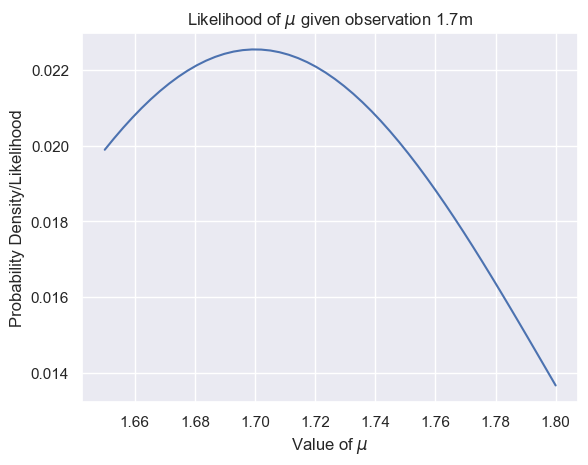

In [53]:
plt.plot(mu, likelihood_out)
plt.title("Likelihood of $\mu$ given observation 1.7m")
plt.ylabel("Probability Density/Likelihood")
plt.xlabel("Value of $\mu$")
plt.show()

In [30]:
unnormalized_posterior = likelihood_out * uniform_dist

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/449817495.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$ in meters")


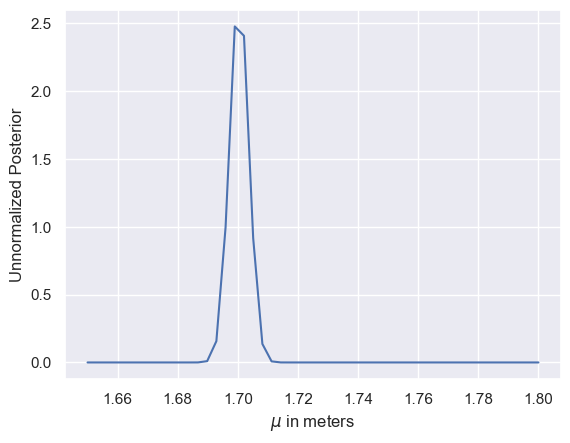

np.float64(7.10694175471837)

In [54]:
plt.plot(mu, unnormalized_posterior)
plt.xlabel("$\mu$ in meters")
plt.ylabel("Unnormalized Posterior")
plt.show()

unnormalized_posterior.sum()

In [32]:
p_data = sp.integrate.trapezoid(unnormalized_posterior, mu)
normalized_posterior = unnormalized_posterior/(p_data)

normalized_posterior

array([6.60814819, 6.70692805, 6.8008084 , 6.88954356, 6.97289908,
       7.05065278, 7.12259571, 7.18853313, 7.24828534, 7.30168854,
       7.34859553, 7.38887642, 7.42241922, 7.44913038, 7.46893517,
       7.48177809, 7.48762307, 7.48645371, 7.47827329, 7.46310478,
       7.44099074, 7.41199312, 7.37619297, 7.33369004, 7.28460236,
       7.22906563, 7.16723268, 7.0992727 , 7.02537049, 6.94572563,
       6.86055158, 6.77007473, 6.67453339, 6.57417674, 6.46926378,
       6.36006219, 6.24684721, 6.12990048, 6.00950889, 5.88596342,
       5.75955797, 5.63058822, 5.49935049, 5.36614063, 5.23125294,
       5.09497911, 4.9576072 , 4.81942069, 4.68069757, 4.54170941])

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/3142790443.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$ in meters")


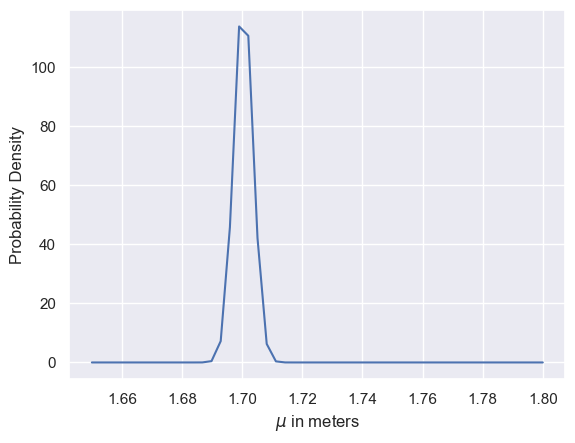

In [55]:
plt.plot(mu, normalized_posterior)
plt.xlabel("$\mu$ in meters")
plt.ylabel("Probability Density")
plt.show()

### Model Fitting - Improvements

In [35]:
heights_data = sp.stats.norm.rvs(loc = 1.7, scale = 0.1, size = 1001)

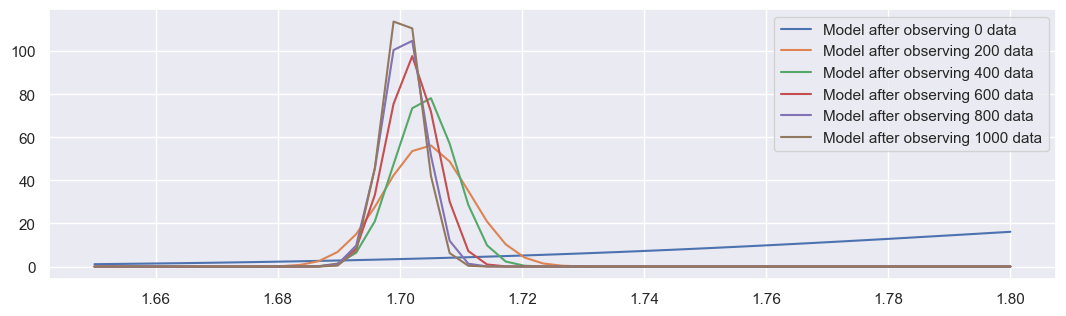

In [56]:
prior = uniform_dist
posterior_dict = {}

plt.figure(figsize = (13, 3.5))

for ind, datum in enumerate(heights_data):
  likelihood = likelihood_func(datum, mu)
  unnormalized_posterior = prior * likelihood
  normalized_posterior = unnormalized_posterior/sp.integrate.trapezoid(unnormalized_posterior, mu)
  prior = normalized_posterior
  posterior_dict[ind] = normalized_posterior
  if ind%200 == 0:
    plt.plot(mu, normalized_posterior, label = f'Model after observing {ind} data')

plt.legend()
plt.show()

In [39]:
def compute_percentile(parameter_values, distribution_values, percentile):
    cumulative_distribution = sp.integrate.cumulative_trapezoid(
        distribution_values, parameter_values)
    percentile_index = np.searchsorted(cumulative_distribution, percentile)
    return parameter_values[percentile_index]


In [58]:
top_bound = means = [compute_percentile(mu, posterior_dict[i], 0.995) for i in range(20, 1001, 20)]
bottom_bound = means = [compute_percentile(mu, posterior_dict[i], 0.005) for i in range(20, 1001, 20)]
means = [compute_percentile(mu, posterior_dict[i], 0.5) for i in range(20, 1001, 20)]

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_16503/2746314498.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Predicted Mean $\mu$")


Text(0, 0.5, 'Predicted Mean $\\mu$')

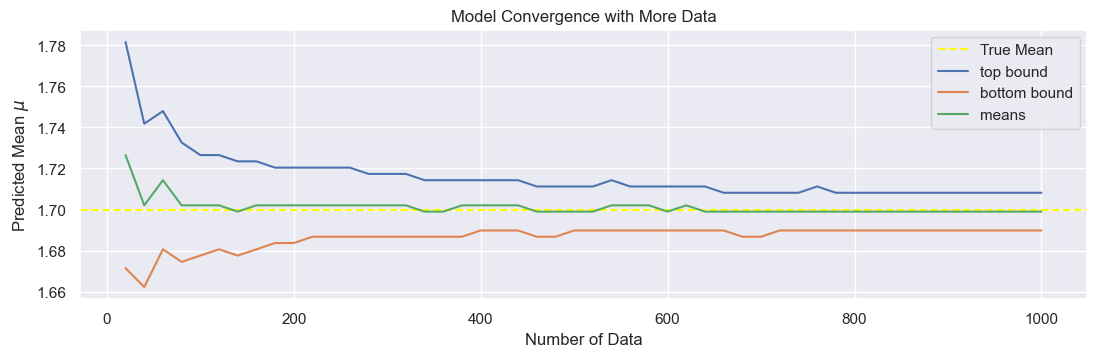

In [59]:
plt.figure(figsize = (13, 3.5))
plt.axhline(y=1.7, ls = '--', color = 'Yellow', label = 'True Mean')
plt.plot(range(20, 1001, 20), top_bound, label = 'top bound')
plt.plot(range(20, 1001, 20), bottom_bound, label = 'bottom bound')
plt.plot(range(20, 1001, 20), means, label = 'means')
plt.legend()
plt.title('Model Convergence with More Data')
plt.xlabel("Number of Data")
plt.ylabel("Predicted Mean $\mu$")

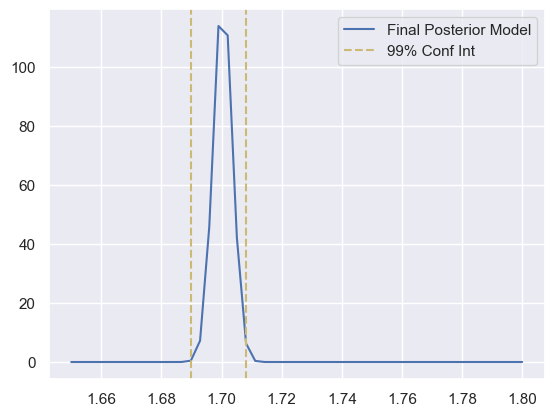

In [60]:
plt.plot(mu, posterior_dict[1000], label = 'Final Posterior Model')
plt.axvline(x = compute_percentile(mu, posterior_dict[1000], 0.005), ls = '--', color = 'y', label = '99% Conf Int')
plt.axvline(x = compute_percentile(mu, posterior_dict[1000], 0.995), ls = '--', color = 'y')
plt.legend()

In [42]:
model = sp.stats.norm(loc=1.699, scale=0.1)

sum(model.rvs(size=100)>1.75)

np.int64(32)

(array([ 8.,  8., 14., 15., 18., 11., 11., 12.,  1.,  2.]),
 array([21. , 23.1, 25.2, 27.3, 29.4, 31.5, 33.6, 35.7, 37.8, 39.9, 42. ]),
 <BarContainer object of 10 artists>)

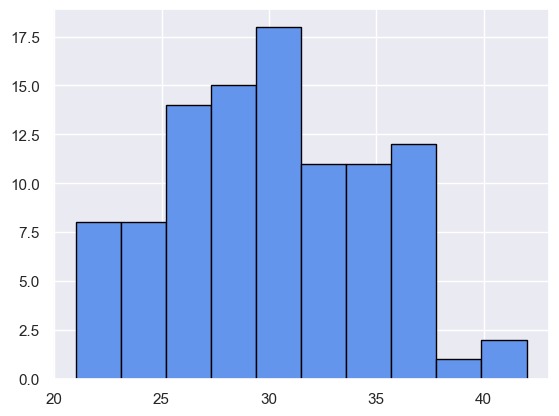

In [61]:
results = model.rvs(size = [100, 100])
results_sum = (results > 1.75).sum(axis = 1)


plt.hist(results_sum, edgecolor = 'black', color = 'cornflowerblue')

Our 99% confidence interval lower bound is: 21.495
Our 99% confidence interval upper bound is: 41.504999999999995


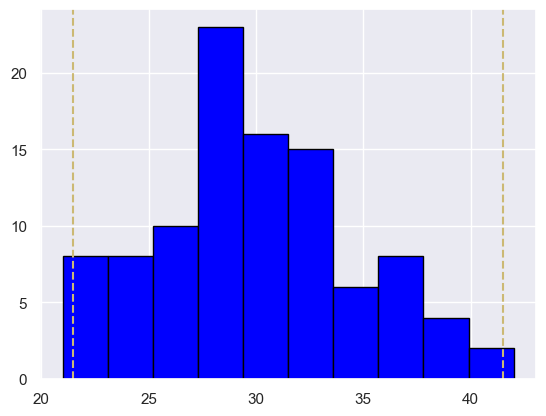

In [64]:
results = model.rvs(size = [100, 100])
results_sum = (results > 1.75).sum(axis = 1)

lower_bound = np.quantile(results_sum, 0.005)
upper_bound = np.quantile(results_sum, 0.995)


plt.hist(results_sum, edgecolor = 'black', color = 'blue')
plt.axvline(x = lower_bound, color = 'y', ls = '--')
plt.axvline(x = upper_bound, color = 'y', ls = '--')

print('Our 99% confidence interval lower bound is:', lower_bound)
print('Our 99% confidence interval upper bound is:', upper_bound)